## Building Basic Chatbot using Langgraph (Graph API)

In [1]:
import os
from dotenv import load_dotenv

from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
load_dotenv()

True

In [3]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
llm=ChatGroq(model="llama-3.1-8b-instant",api_key=os.getenv("GROQ_API"))

In [4]:
llm2=init_chat_model("groq:llama-3.1-8b-instant", api_key=os.getenv("GROQ_API"))

In [5]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)

In [6]:
def chatbot_node(state:State):
    return{"messages":[llm2.invoke(state["messages"])]}

In [7]:
# building state graph

# adding nodes
graph_builder.add_node("llmbasicbot",chatbot_node)

# adding edges
graph_builder.add_edge(START,"llmbasicbot")
graph_builder.add_edge("llmbasicbot",END)

# compiling graph

graph=graph_builder.compile()



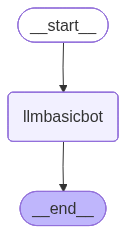

In [8]:
## visualising graph 
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error Occured : {e}")

In [9]:
responses=graph.invoke({"messages":"Hi"})

In [10]:
responses=graph.invoke({"messages":"what is AI"})

In [11]:
responses["messages"][-1]

AIMessage(content='AI, or Artificial Intelligence, refers to the simulation of human intelligence in machines that are programmed to think and learn like humans. The term can also be applied to any machine that exhibits traits associated with a human mind such as learning and problem-solving.\n\nArtificial intelligence involves the use of algorithms, data, and computational power to enable machines to perform tasks that would normally require human intelligence, such as:\n\n1. **Learning**: AI systems can learn from data, experiences, and interactions.\n2. **Problem-solving**: AI systems can identify and solve complex problems, often using reasoning and decision-making algorithms.\n3. **Perception**: AI systems can interpret and understand data from sensors, such as images, speech, and text.\n4. **Reasoning**: AI systems can draw inferences and make decisions based on data and logic.\n\nThere are several types of AI, including:\n\n1. **Narrow or Weak AI**: Designed to perform a specifi

In [12]:
for events in graph.stream({"messages":"Hey! How are you?"}):
    print (events)


{'llmbasicbot': {'messages': [AIMessage(content="I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or topics you'd like to discuss. How about you? How's your day going?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 41, 'total_tokens': 91, 'completion_time': 0.068643038, 'completion_tokens_details': None, 'prompt_time': 0.002968907, 'prompt_tokens_details': None, 'queue_time': 0.052371813, 'total_time': 0.071611945}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eddc5-19b5-7a03-87df-e0288d482048-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 50, 'total_tokens': 91})]}}


In [13]:
for events in graph.stream({"messages":"Hey! How are you?"}):
    for values in events.values():
        print (values)


{'messages': [AIMessage(content="I'm functioning properly, thank you for asking. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 41, 'total_tokens': 59, 'completion_time': 0.02477988, 'completion_tokens_details': None, 'prompt_time': 0.004046693, 'prompt_tokens_details': None, 'queue_time': 0.057998962, 'total_time': 0.028826573}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eddc5-1bde-7c92-92bb-3c2c851834bb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 18, 'total_tokens': 59})]}


In [14]:
for events in graph.stream({"messages":"Hey! How are you?"}):
    for values in events.values():
        print (values["messages"][-1].content)

I'm doing well, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm here to help you with any questions or tasks you may have. How can I assist you today?


In [15]:
for events in graph.stream({"messages":"Hey! Could you please provide me live news about FIFA world cup match"}):
    for values in events.values():
        print (values["messages"][-1].content)

I'm not capable of providing real-time news or updates. However, I can provide you with general information and updates about the FIFA World Cup.

That being said, here are a few options to get live news and updates about the FIFA World Cup:

1. **Official FIFA Website**: The official FIFA website (fifa.com) provides live scores, news, and updates about the World Cup.
2. **News Websites**: Websites like BBC Sport, ESPN, and Al Jazeera provide live coverage of the World Cup, including news, scores, and analysis.
3. **Social Media**: Follow official FIFA social media accounts (Twitter, Instagram, Facebook) and news organizations to get live updates and news about the World Cup.
4. **Sports Apps**: Download sports apps like the FIFA World Cup app, BBC Sport app, or ESPN app to get live scores, news, and updates about the World Cup.
5. **Live TV**: Watch the World Cup live on TV channels like BBC, ITV, or other local channels that broadcast the tournament.

Please note that the information

In [16]:
##Adding External Tools

## Chatbot with tools

from langchain_tavily import TavilySearch

tool= TavilySearch(max_results=2,tavily_api_key=os.getenv("TAVILY_API_KEY"))
tool.invoke("What is Langchain and Langgraph")

{'query': 'What is Langchain and Langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/artificial-intelligence/langchain-vs-langgraph',
   'title': 'LangChain vs. LangGraph - GeeksforGeeks',
   'content': 'LangChain and LangGraph are tools that help build AI workflows. LangChain works in a step by step way, while LangGraph allows more flexible paths. LangChain is a framework designed to connect large language models into structured workflows enabling multi step reasoning and automation. LangGraph is a framework that organizes large language models into graph based workflows enabling flexible and parallel multi step reasoning. | Goal | Connects steps in order for structured, multi step reasoning | Builds flexible workflows using graph style task flow |. | Flow Type | Works in a straight, step by step manner | Supports parallel, conditional and adaptive paths |. | Ease of Implementation | Simple to use for straightfo

In [17]:
## Custom Function

def multiply(a:int,b:int)->int:
    """
    Multiply a and b 
    Args:
    a(first int)
    b(second int)

    Returns:
        int: output int
    """
    return a*b

In [18]:
tools=[tool,multiply]

In [19]:
llm_with_tools=llm.bind_tools(tools)

In [20]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.7', 'langchain': '1.3.9'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x1138dd010>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1138dda90>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for

In [21]:
## Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node definition
def tool_calling_llm(state:State):
    return{"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools=tools))

## Add edges

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
## IF the input from llm requires tool calling then it will go to tools node else shall just go to END node
builder.add_edge("tools",END)

graph=builder.compile()




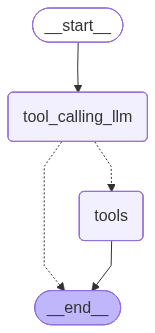

In [22]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
response=graph.invoke({"messages":"What is the recent FIFA world cup 2026 match score."})

In [26]:
response["messages"][-1].content

'{"query": "FIFA world cup 2026 match score", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.theguardian.com/football/live/2024/dec/13/world-cup-2026-qualifying-draw-premier-league-news-live", "title": "World Cup 2026 qualifying draw and Premier League news – live - The Guardian", "score": 0.30278313, "published_date": "Fri, 13 Dec 2024 10:01:29 GMT", "content": "Elsewhere, there are plenty of press conferences as the Premier League continues this weekend. Newcastle’s Eddie Howe and Liverpool’s Arne Slot are both talking this morning, with Ange Postecoglou, Pep Guardiola and Mikel Arteta coming up later. We’ll also try to keep you updated on all the day’s developing football news.\\n\\nShare\\n\\nExplore more on these topics\\n\\n   World Cup 2026\\n   Weekend football countdown\\n   World Cup\\n   Premier League\\n\\nShare\\n\\nReuse this content\\n\\nMost viewed\\n\\nMost viewed\\n\\n   Football\\n   Live scores\\n   Tables\\n   Fixtures\\

In [27]:
for message in response["messages"]:
    print(message.pretty_print())

================================ Human Message =================================

What is the recent FIFA world cup 2026 match score.
None
================================== Ai Message ==================================
Tool Calls:
  tavily_search (1dhd3j5k4)
 Call ID: 1dhd3j5k4
  Args:
    end_date: 2024-12-31
    query: FIFA world cup 2026 match score
    search_depth: advanced
    start_date: 2024-01-01
    topic: news
None
================================= Tool Message =================================
Name: tavily_search

{"query": "FIFA world cup 2026 match score", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.theguardian.com/football/live/2024/dec/13/world-cup-2026-qualifying-draw-premier-league-news-live", "title": "World Cup 2026 qualifying draw and Premier League news – live - The Guardian", "score": 0.30278313, "published_date": "Fri, 13 Dec 2024 10:01:29 GMT", "content": "Elsewhere, there are plenty of press conferences as the P

In [28]:
response=graph.invoke({"messages":"What is 104587695 multiplied by 95485."})

In [29]:
for response in response["messages"]:
    response.pretty_print()

================================ Human Message =================================

What is 104587695 multiplied by 95485.
================================== Ai Message ==================================
Tool Calls:
  multiply (m1z1js2my)
 Call ID: m1z1js2my
  Args:
    a: 104587695
    b: 95485
================================= Tool Message =================================
Name: multiply

9986556057075


In [30]:
response=graph.invoke({"messages":"What is 104587695 multiplied by 95485. And also give me latest news for SpaceX IPO in june 2026"})

In [31]:
for response in response["messages"]:
    response.pretty_print()

================================ Human Message =================================

What is 104587695 multiplied by 95485. And also give me latest news for SpaceX IPO in june 2026
================================== Ai Message ==================================
Tool Calls:
  multiply (42v49t4t6)
 Call ID: 42v49t4t6
  Args:
    a: 104587695
    b: 95485
================================= Tool Message =================================
Name: multiply

9986556057075


In [32]:
def add(a: int, b: float)->float:
    """Adding a and b
    
    Args:
        a (first int)
        b (Second float)

    Returns:
        float: output float
    """
    return a+b

def divide(a: float, b: float)->float:
    """divide a by b
    
    Args:
        a (first float)
        b (Second float)

    Returns:
        float: output float
    """
    return a/b

In [33]:
tools2=[tool,multiply,add,divide]

In [34]:
llm_with_tools_updated=llm.bind_tools(tools=tools2)

In [35]:
## ReACT Agent architecture. Act, Observe and Reason.

## Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node definition
def tool_calling_llm_updated(state:State):
    return{"messages":[llm_with_tools_updated.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm_updated",tool_calling_llm_updated)
builder.add_node("tools",ToolNode(tools=tools))

## Add edges

builder.add_edge(START,"tool_calling_llm_updated")
builder.add_conditional_edges("tool_calling_llm_updated",tools_condition)
## IF the input from llm requires tool calling then it will go to tools node else shall just go to END node
builder.add_edge("tools","tool_calling_llm_updated")

graph=builder.compile()


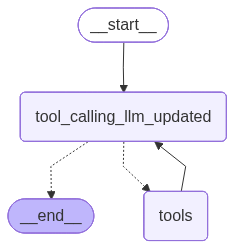

In [36]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [37]:
response=graph.invoke({"messages":"What is 104587695 multiplied by 95485. And also give me latest news for SpaceX IPO in june 2026. Could you please add 46 and 24, then divide the result by 4.0"})

In [38]:
for response in response["messages"]:
    response.pretty_print()

================================ Human Message =================================

What is 104587695 multiplied by 95485. And also give me latest news for SpaceX IPO in june 2026. Could you please add 46 and 24, then divide the result by 4.0
================================== Ai Message ==================================
Tool Calls:
  multiply (kkppbxdp4)
 Call ID: kkppbxdp4
  Args:
    a: 104587695
    b: 95485
  tavily_search (3bwwh9acr)
 Call ID: 3bwwh9acr
  Args:
    end_date: None
    query: SpaceX IPO news june 2026
    time_range: month
    topic: news
  add (k3n0mnbey)
 Call ID: k3n0mnbey
  Args:
    a: 46
    b: 24
  divide (mk2125624)
 Call ID: mk2125624
  Args:
    a: 70
    b: 4
================================= Tool Message =================================
Name: multiply

9986556057075
================================= Tool Message =================================
Name: tavily_search

{"query": "SpaceX IPO news june 2026", "follow_up_questions": null, "answer": null, "ima